In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import phys_grad, compute_core_mean


In [2]:
# df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_beta_data_w.pkl')
# df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
# df_eddies = df_eddies.merge(
#     df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
#     how='left',
#     left_on=['Eddy', 'Day'],
#     right_on=['Eddy', 'Day']
# )
dic_vert = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/dic_vert_doppio_50m_vert_checked.pkl')


In [3]:
# Field Data
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [4]:
prop_dist = (
    df_eddies
    .groupby('Eddy')[['xc', 'yc']]
    .apply(lambda g: np.nansum(np.hypot(g.xc.diff(), g.yc.diff())))
)
df_eddies['PropDist'] = df_eddies['Eddy'].map(prop_dist)

# Most moved AE
df_AE = df_eddies[df_eddies.Cyc == 'AE']
# ae_eddy = df_AE[df_AE.PropDist.max() == df_AE.PropDist].Eddy.unique()[0]
ae_eddy = df_AE.groupby('Eddy')['lat'].agg(np.ptp).idxmax()
df_ae_eddy = df_eddies[df_eddies.Eddy==ae_eddy].copy()

# Most moved lat CE
df_CE = df_eddies[df_eddies.Cyc == 'CE']
# ce_eddy = df_CE[df_CE.PropDist.max() == df_CE.PropDist].Eddy.unique()[0]
ce_eddy = df_CE.groupby('Eddy')['lat'].agg(np.ptp).idxmax()
df_ce_eddy = df_eddies[df_eddies.Eddy==ce_eddy].copy()


# # oldest AE
# df_AE = df_eddies[df_eddies.Cyc == 'AE']
# ae_eddy = df_AE[df_AE.Age.max()==df_AE.Age].iloc[0].Eddy
# df_ae_eddy = df_eddies[df_eddies.Eddy==ae_eddy].copy()

# # oldest CE
# df_CE = df_eddies[df_eddies.Cyc == 'CE']
# ce_eddy = df_CE[df_CE.Age.max()==df_CE.Age].iloc[0].Eddy
# df_ce_eddy = df_eddies[df_eddies.Eddy==ce_eddy].copy()


ae_eddy, ce_eddy


(np.int64(2350), np.int64(31))

In [15]:
df_ae_eddy

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,dy_top,EddyProp,x_btm,y_btm,dx_btm,dy_btm,btm_prop,sep_km,sep_rate_ms,top_btm_diff
100710,2350,8791,AE,154.879751,-27.025659,99,290,260.911777,1432.575037,0.000029,...,NaN,NaN,260.316355,1389.678642,NaN,NaN,NaN,42.900527,NaN,NaN
100711,2350,8792,AE,154.804597,-27.185328,98,286,259.622074,1413.433880,0.000042,...,-19.141157,0.222043,263.894425,1380.677331,3.578070,-9.001311,0.112111,33.033990,-0.114196,0.130182
100712,2350,8793,AE,154.803543,-27.351484,101,283,265.486088,1396.114324,0.000045,...,-17.319556,0.211636,265.549548,1375.325024,1.655123,-5.352307,0.064842,20.789397,-0.141720,0.146827
100713,2350,8794,AE,154.804770,-27.493654,103,280,270.693971,1381.364380,0.000043,...,-14.749944,0.181046,268.569205,1367.692950,3.019657,-7.632074,0.094997,13.835557,-0.080484,0.086188
100714,2350,8795,AE,154.806649,-27.640575,105,277,276.124734,1366.139901,0.000043,...,-15.224479,0.187084,283.944688,1348.839426,15.375483,-18.853524,0.281576,18.985735,0.059609,0.122525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100902,2350,8983,AE,153.057427,-34.279973,134,125,351.046787,617.674347,0.000026,...,4.242978,0.077441,351.581913,513.815963,2.235942,-71.484291,0.827769,103.859763,0.866909,0.880658
100903,2350,8984,AE,152.957945,-34.285184,131,124,342.548019,614.011078,0.000026,...,-3.663268,0.107114,343.051156,607.523087,-8.530757,93.707124,1.089058,6.507471,-1.126763,1.126972
100904,2350,8985,AE,152.892765,-34.292356,129,124,337.110972,611.219844,0.000021,...,-2.791234,0.070737,356.473169,496.042354,13.422013,-111.480733,1.299604,116.793617,1.276460,1.276777
100905,2350,8986,AE,152.856881,-34.210955,127,125,331.174576,618.579706,0.000024,...,7.359862,0.109440,328.957922,601.242261,-27.515247,105.199907,1.258550,17.478574,-1.149480,1.159623


In [6]:
kmday_to_ms = 1000 / 86400

def add_top_bottom_speeds(df, dic_vert):
    df = df.copy()

    # --- top-centre displacement + propagation speed ---
    df['dx_top'] = df.groupby('Eddy')['xc'].diff()
    df['dy_top'] = df.groupby('Eddy')['yc'].diff()
    df['EddyProp'] = np.hypot(df['dx_top'], df['dy_top']) * kmday_to_ms

    # --- bottom-centre positions ---
    x_btm, y_btm = [], []

    for _, row0 in df.iterrows():

        eddy_id = int(row0.Eddy)
        day_id  = int(row0.Day)

        eddy_key = f'Eddy{eddy_id}'
        day_key  = f'Day{day_id}'

        if eddy_key in dic_vert and day_key in dic_vert[eddy_key]:

            dvert = dic_vert[eddy_key][day_key]

            if len(dvert):
                d = dvert[dvert.Depth.abs() < 1000]
                row_btm = d.iloc[-1] if len(d) else dvert.iloc[-1]

                x_btm.append(row_btm.xc)
                y_btm.append(row_btm.yc)

            else:
                x_btm.append(np.nan)
                y_btm.append(np.nan)

        else:
            x_btm.append(np.nan)
            y_btm.append(np.nan)

    df['x_btm'] = x_btm
    df['y_btm'] = y_btm

    # --- bottom-centre displacement + propagation speed ---
    df['dx_btm'] = df.groupby('Eddy')['x_btm'].diff()
    df['dy_btm'] = df.groupby('Eddy')['y_btm'].diff()
    df['btm_prop'] = np.hypot(df['dx_btm'], df['dy_btm']) * kmday_to_ms

    # --- surface-bottom separation ---
    df['sep_km'] = np.hypot(
        df['x_btm'] - df['xc'],
        df['y_btm'] - df['yc']
    )

    df['sep_rate_ms'] = df.groupby('Eddy')['sep_km'].diff() * kmday_to_ms

    # --- vector difference between top and bottom propagation ---
    df['top_btm_diff'] = np.hypot(
        df['dx_btm'] - df['dx_top'],
        df['dy_btm'] - df['dy_top']
    ) * kmday_to_ms

    return df

df_ae_eddy = add_top_bottom_speeds(df_ae_eddy, dic_vert)
df_ce_eddy = add_top_bottom_speeds(df_ce_eddy, dic_vert)


In [7]:
def plot_best_fit(
    x, y,
    ax=None,
    xlabel='',
    scatter_kwargs=None,
    line_kwargs=None,
    text_loc=(0.03, 0.97),
    clr='b'
):

    if ax is None:
        ax = plt.gca()

    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    scatter_kwargs = {} if scatter_kwargs is None else scatter_kwargs
    line_kwargs = {'color': 'k', 'lw': 2} | (line_kwargs or {})

    ax.scatter(x, y, marker='.', alpha=0.4, **scatter_kwargs, color=clr)

    m, b = np.polyfit(x, y, 1)

    xx = np.array([x.min(), x.max()])
    ax.plot(xx, m*xx + b, **line_kwargs)

    yhat = m*x + b
    r2 = 1 - np.sum((y-yhat)**2) / np.sum((y-y.mean())**2)

    ax.text(
        *text_loc,
        f'$m$={m:.2g}\n$R^2$={r2:.2f}',
        transform=ax.transAxes,
        va='top'
    )

    ax.set_xlabel(xlabel)

    return m, b, r2
    

Text(0.5, 0.98, 'AE2350')

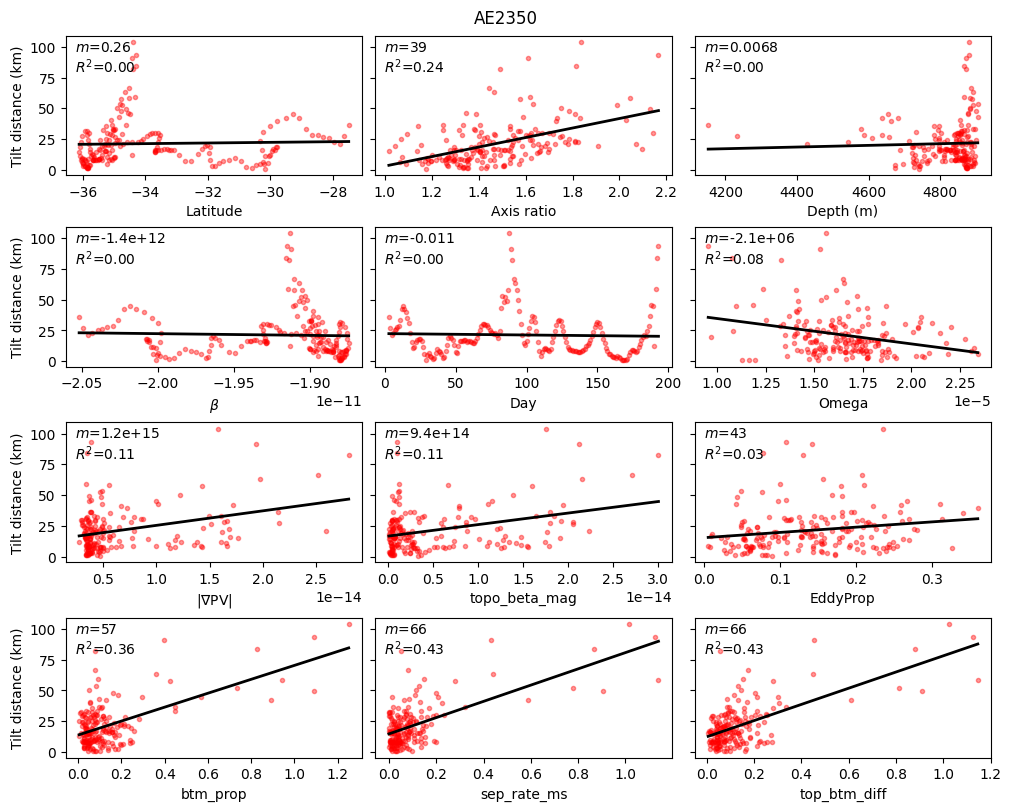

In [14]:
fig, axs = plt.subplots(
    4, 3,
    figsize=(10, 8),
    sharey=True,
    constrained_layout=True
)

axs = axs.ravel()

df = df_ae_eddy.copy()
clr = 'r'

plot_best_fit(df.lat, df.TiltDis, ax=axs[0], xlabel='Latitude', clr=clr)

plot_best_fit(df.AR, df.TiltDis, ax=axs[1], xlabel='Axis ratio', clr=clr)

df['h'] = h[df.ic, df.jc]
plot_best_fit(df.h, df.TiltDis, ax=axs[2], xlabel='Depth (m)', clr=clr)

dfdx, dfdy = phys_grad(f, X_grid*1e3, Y_grid*1e3, mask_rho)
df_dN = -(np.sin(angle) * dfdx + np.cos(angle) * dfdy)
df['beta'] = df_dN[df.ic, df.jc]
plot_best_fit(df.beta, df.TiltDis, ax=axs[3], xlabel=r'$\beta$', clr=clr)

plot_best_fit(df.Day-df.Day.iloc[0], df.TiltDis, ax=axs[4], xlabel='Day', clr=clr)

plot_best_fit(df.Omega, df.TiltDis, ax=axs[5], xlabel='Omega', clr=clr)

plot_best_fit(df.PV_grad_mag, df.TiltDis, ax=axs[6], xlabel=r'|$\nabla$PV|', clr=clr)

plot_best_fit(df.topo_beta_mag, df.TiltDis, ax=axs[7], xlabel='topo_beta_mag', clr=clr)

plot_best_fit(df.EddyProp, df.TiltDis, ax=axs[8], xlabel='EddyProp', clr=clr)

plot_best_fit(df.btm_prop, df.TiltDis, ax=axs[9], xlabel='btm_prop', clr=clr)

plot_best_fit(df.sep_rate_ms.abs(), df.TiltDis, ax=axs[10], xlabel='sep_rate_ms', clr=clr)

plot_best_fit(df.top_btm_diff, df.TiltDis, ax=axs[11], xlabel='top_btm_diff', clr=clr)

axs[0].set_ylabel('Tilt distance (km)')
axs[3].set_ylabel('Tilt distance (km)')
axs[6].set_ylabel('Tilt distance (km)')
axs[9].set_ylabel('Tilt distance (km)')

plt.suptitle(f'AE{ae_eddy}')


Text(0.5, 0.98, 'CE31')

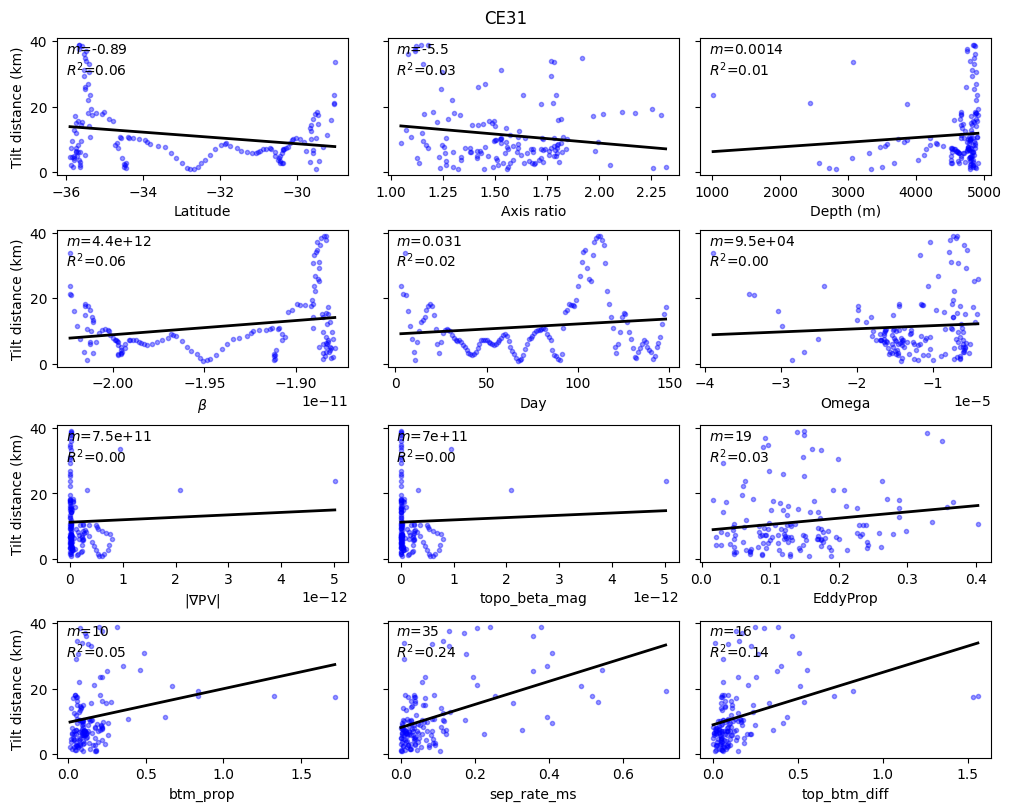

In [13]:
fig, axs = plt.subplots(
    4, 3,
    figsize=(10, 8),
    sharey=True,
    constrained_layout=True
)

axs = axs.ravel()

df = df_ce_eddy.copy()
clr = 'b'

plot_best_fit(df.lat, df.TiltDis, ax=axs[0], xlabel='Latitude', clr=clr)

plot_best_fit(df.AR, df.TiltDis, ax=axs[1], xlabel='Axis ratio', clr=clr)

df['h'] = h[df.ic, df.jc]
plot_best_fit(df.h, df.TiltDis, ax=axs[2], xlabel='Depth (m)', clr=clr)

dfdx, dfdy = phys_grad(f, X_grid*1e3, Y_grid*1e3, mask_rho)
df_dN = -(np.sin(angle) * dfdx + np.cos(angle) * dfdy)
df['beta'] = df_dN[df.ic, df.jc]
plot_best_fit(df.beta, df.TiltDis, ax=axs[3], xlabel=r'$\beta$', clr=clr)

plot_best_fit(df.Day-df.Day.iloc[0], df.TiltDis, ax=axs[4], xlabel='Day', clr=clr)

plot_best_fit(df.Omega, df.TiltDis, ax=axs[5], xlabel='Omega', clr=clr)

plot_best_fit(df.PV_grad_mag, df.TiltDis, ax=axs[6], xlabel=r'|$\nabla$PV|', clr=clr)

plot_best_fit(df.topo_beta_mag, df.TiltDis, ax=axs[7], xlabel='topo_beta_mag', clr=clr)

plot_best_fit(df.EddyProp, df.TiltDis, ax=axs[8], xlabel='EddyProp', clr=clr)

plot_best_fit(df.btm_prop, df.TiltDis, ax=axs[9], xlabel='btm_prop', clr=clr)

plot_best_fit(df.sep_rate_ms.abs(), df.TiltDis, ax=axs[10], xlabel='sep_rate_ms', clr=clr)

plot_best_fit(df.top_btm_diff, df.TiltDis, ax=axs[11], xlabel='top_btm_diff', clr=clr)

axs[0].set_ylabel('Tilt distance (km)')
axs[3].set_ylabel('Tilt distance (km)')
axs[6].set_ylabel('Tilt distance (km)')
axs[9].set_ylabel('Tilt distance (km)')

plt.suptitle(f'CE{ce_eddy}')


(np.float64(0.0),
 np.float64(988.1356688684336),
 np.float64(0.0),
 np.float64(1561.702894718129))

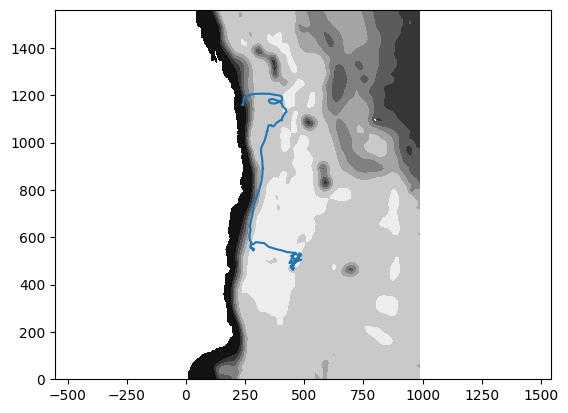

In [10]:
plt.contourf(X_grid, Y_grid, np.where(mask_rho, h, np.nan), cmap='grey')
plt.plot(df.xc, df.yc)
plt.axis('equal')


NameError: name 'eddy' is not defined

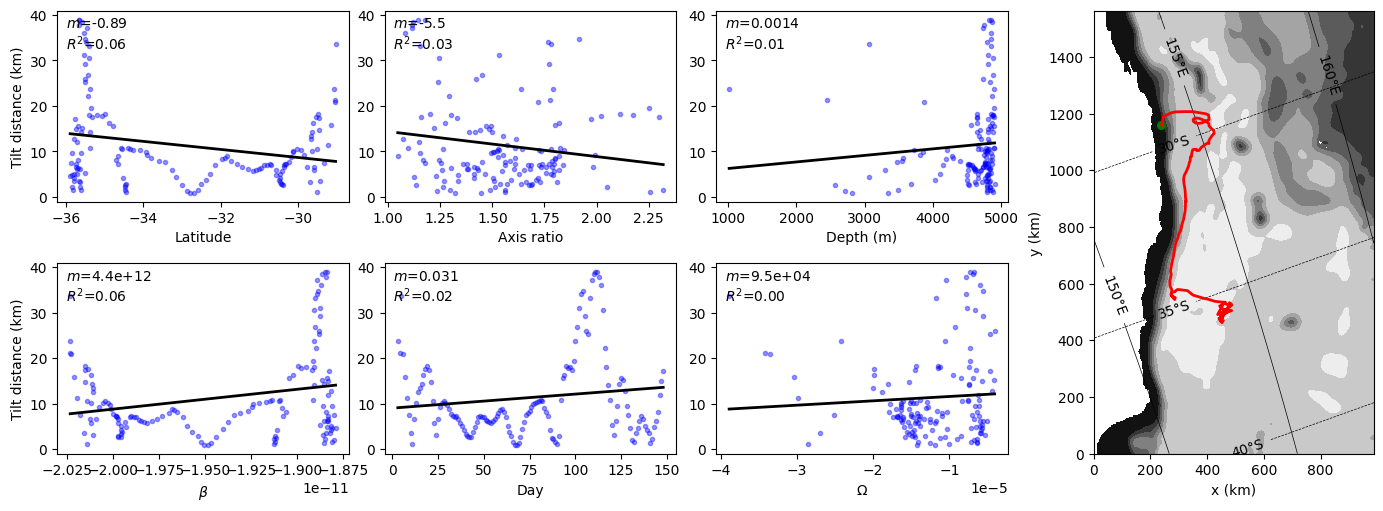

In [11]:
fig = plt.figure(figsize=(14, 5), constrained_layout=True)

gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 1.15])

axs = np.array([
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
])

ax_map = fig.add_subplot(gs[:, 3])

plot_best_fit(df.lat, df.TiltDis, ax=axs[0], xlabel='Latitude')
plot_best_fit(df.AR, df.TiltDis, ax=axs[1], xlabel='Axis ratio')

df['h'] = h[df.ic, df.jc]
plot_best_fit(df.h, df.TiltDis, ax=axs[2], xlabel='Depth (m)')
# plot_best_fit(df.w, df.TiltDis, ax=axs[2], xlabel=r'$\omega$')

dfdx, dfdy = phys_grad(f, X_grid*1e3, Y_grid*1e3, mask_rho)
df_dN = -(np.sin(angle) * dfdx + np.cos(angle) * dfdy)

df['beta'] = df_dN[df.ic, df.jc]
plot_best_fit(df.beta, df.TiltDis, ax=axs[3], xlabel=r'$\beta$')

plot_best_fit(df.Day - df.Day.iloc[0], df.TiltDis, ax=axs[4], xlabel='Day')

plot_best_fit(df.Omega, df.TiltDis, ax=axs[5], xlabel=r'$\Omega$')

axs[0].set_ylabel('Tilt distance (km)')
axs[3].set_ylabel('Tilt distance (km)')

ax_map.contourf(
    X_grid,
    Y_grid,
    np.where(mask_rho, h, np.nan),
    cmap='grey'
)
c1 = ax_map.contour(X_grid, Y_grid, lat_rho, levels=[-40, -35, -30, -25], colors='k', linewidths=.5)
ax_map.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')
c2 = ax_map.contour(X_grid, Y_grid, lon_rho, levels=[150, 155, 160], colors='k', linewidths=.5)
ax_map.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')
    
ax_map.plot(df.xc, df.yc, color='r', lw=2)
ax_map.scatter(df.xc.iloc[0], df.yc.iloc[0], color='g', s=30, label='Start')
# ax_map.scatter(df.xc.iloc[-1], df.yc.iloc[-1], color='r', s=30, label='End')


ax_map.set_aspect('equal')
ax_map.set_xlabel('x (km)')
ax_map.set_ylabel('y (km)')
ax_map.set_title(f'Eddy{eddy}')
ax_map.legend(frameon=False, loc='lower right')



In [ ]:
df.columns